# Assignment 5.1
## Build an Explainable Bayesian Network for Heart Failure Prediction

In real medical AI systems today, doctors and regulators frequently reject black-box models (even if they are slightly more accurate) because they cannot explain why a patient was classified as high-risk. Bayesian Networks solve this problem and are still used in clinical decision support tools.

Your assignment is to use the Heart Failure Prediction dataset (https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) to do the following:

1. Exploratory Data Analysis
    * Produce at least four insightful plots
    * Write 3–5 sentences summarising the most important risk factors you observe

======== Preview of Data ========

Sample of the data:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  ExerciseAngina_bin Age_bin  \
0              N      0.0       Up             0                   0   40-59   
1              N      1.0     Flat             1                   0   40-59   
2              N      0.0       Up             0                   0     <40   
3              Y      1.5     Flat             1                   1   40-59   
4              N      0.0       Up             0          

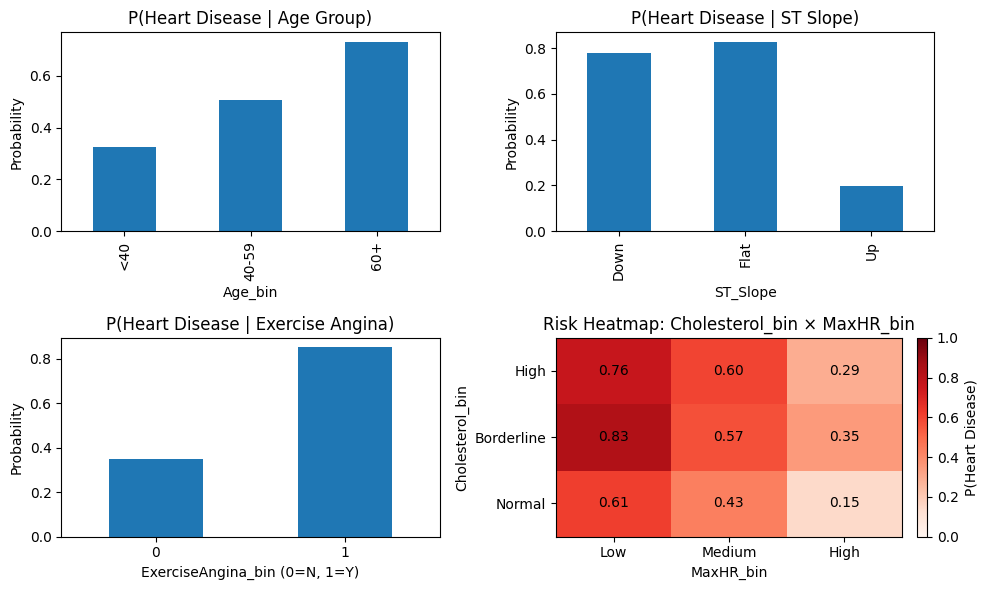


EDA Summary (3–5 sentences):
Baseline prevalence is P(HeartDisease=1) = 0.553. Risk increases strongly with age: Age_bin=60+ has P(HD=1) ≈ 0.731.
ST_Slope is highly informative: ST_Slope='Flat' has P(HD=1) ≈ 0.828, while 'Up' is substantially lower in this dataset.
Exercise-induced angina is one of the strongest indicators: ExerciseAngina=1 has P(HD=1) ≈ 0.852.
Cholesterol alone is not perfectly monotonic, but the Cholesterol×MaxHR heatmap shows a clear high-risk region (High cholesterol + Low MaxHR), suggesting a conditional/interaction-like relationship.



In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textwrap import dedent
import networkx as nx

from pgmpy.estimators import HillClimbSearch, BicScore, BayesianEstimator
from pgmpy.models import BayesianNetwork
from pgmpy.inference import VariableElimination

# second structure-learning score (BDeu if available; otherwise K2 as fallback)
try:
    from pgmpy.estimators import BDeuScore
    SCORE_NAME_2 = "BDeuScore"
except Exception:
    from pgmpy.estimators import K2Score
    SCORE_NAME_2 = "K2Score"

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score


# ============================================================
# 0) Load data
# ============================================================
df = pd.read_csv("heart_failure_prediction.csv")


# ============================================================
# 1) Cleaning + Binning (discretization for CPTs + interpretability)
# ============================================================

# Cholesterol shouldn't be zero: replace zeros with median of non-zero values
df["Cholesterol"] = df["Cholesterol"].replace(
    0, df.loc[df["Cholesterol"] > 0, "Cholesterol"].median()
)

# RestingBP shouldn't be zero: replace zeros with median of non-zero values
df["RestingBP"] = df["RestingBP"].replace(
    0, df.loc[df["RestingBP"] > 0, "RestingBP"].median()
)

# ExerciseAngina remap: {Y,N} -> {1,0} to match assignment text
df["ExerciseAngina_bin"] = df["ExerciseAngina"].map({"N": 0, "Y": 1}).astype(int)

# Age bins (required by assignment queries)
df["Age_bin"] = pd.cut(
    df["Age"],
    bins=[0, 39, 59, 100],
    labels=["<40", "40-59", "60+"],
)

# Oldpeak bins
df["Oldpeak_bin"] = pd.cut(
    df["Oldpeak"],
    bins=[-np.inf, 1, 2, np.inf],
    labels=["Normal", "Moderate", "High"],
)

# Cholesterol bins (standard-ish cutoffs)
df["Cholesterol_bin"] = pd.cut(
    df["Cholesterol"],
    bins=[0, 200, 240, np.inf],
    labels=["Normal", "Borderline", "High"],
)

# MaxHR bins (quantile-based so bins are populated)
q1, q2 = df["MaxHR"].quantile([0.33, 0.66])
df["MaxHR_bin"] = pd.cut(
    df["MaxHR"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Low", "Medium", "High"],
)

# RestingBP bins (clinically interpretable, simple)
df["RestingBP_bin"] = pd.cut(
    df["RestingBP"],
    bins=[0, 120, 140, np.inf],
    labels=["Normal", "Elevated", "High"],
)


# ============================================================
# 2) Dataset Overview
# ============================================================
print("======== Preview of Data ========")
print(f"\nSample of the data:\n{df.head()}")
print(f"\n(Rows, Columns) = {df.shape}")
df.info()
print(f"\nDescribe (numeric data):\n{df.describe()}")
print(f"\nNumber of duplicated rows: {df.duplicated().sum()}")


# ============================================================
# 3) EDA: 4 plots
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()

# 1) P(HeartDisease=1 | Age_bin)
ax = axes[0]
pd.crosstab(df["Age_bin"], df["HeartDisease"], normalize="index")[1].plot(kind="bar", ax=ax)
ax.set_title("P(Heart Disease | Age Group)")
ax.set_ylabel("Probability")
ax.set_xlabel("Age_bin")

# 2) P(HeartDisease=1 | ST_Slope)
ax = axes[1]
pd.crosstab(df["ST_Slope"], df["HeartDisease"], normalize="index")[1].plot(kind="bar", ax=ax)
ax.set_title("P(Heart Disease | ST Slope)")
ax.set_ylabel("Probability")
ax.set_xlabel("ST_Slope")

# 3) P(HeartDisease=1 | ExerciseAngina_bin)
ax = axes[2]
pd.crosstab(df["ExerciseAngina_bin"], df["HeartDisease"], normalize="index")[1].plot(kind="bar", ax=ax)
ax.set_title("P(Heart Disease | Exercise Angina)")
ax.set_ylabel("Probability")
ax.set_xlabel("ExerciseAngina_bin (0=N, 1=Y)")
ax.set_xticklabels(["0", "1"], rotation=0)

# 4) Heatmap: P(HeartDisease=1 | Cholesterol_bin, MaxHR_bin)
ax = axes[3]
chol_order = ["Normal", "Borderline", "High"]
hr_order = ["Low", "Medium", "High"]

heat = pd.crosstab(
    df["Cholesterol_bin"],
    df["MaxHR_bin"],
    values=df["HeartDisease"],
    aggfunc="mean",
).reindex(index=chol_order, columns=hr_order)

heat = heat.fillna(0)

im = ax.imshow(
    heat.values,
    origin="lower",
    aspect="auto",
    vmin=0,
    vmax=1,
    cmap="Reds",
)

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title("Risk Heatmap: Cholesterol_bin × MaxHR_bin")
ax.set_xlabel("MaxHR_bin")
ax.set_ylabel("Cholesterol_bin")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.iat[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="P(Heart Disease)")

plt.tight_layout()
plt.show()

# EDA risk-factor summary (3–5 sentences)
p_base_eda = df["HeartDisease"].mean()
p_age_60 = pd.crosstab(df["Age_bin"], df["HeartDisease"], normalize="index")[1].loc["60+"]
p_flat = pd.crosstab(df["ST_Slope"], df["HeartDisease"], normalize="index")[1].loc["Flat"]
p_ex1 = pd.crosstab(df["ExerciseAngina_bin"], df["HeartDisease"], normalize="index")[1].loc[1]

print(dedent(f"""
EDA Summary (3–5 sentences):
Baseline prevalence is P(HeartDisease=1) = {p_base_eda:.3f}. Risk increases strongly with age: Age_bin=60+ has P(HD=1) ≈ {p_age_60:.3f}.
ST_Slope is highly informative: ST_Slope='Flat' has P(HD=1) ≈ {p_flat:.3f}, while 'Up' is substantially lower in this dataset.
Exercise-induced angina is one of the strongest indicators: ExerciseAngina=1 has P(HD=1) ≈ {p_ex1:.3f}.
Cholesterol alone is not perfectly monotonic, but the Cholesterol×MaxHR heatmap shows a clear high-risk region (High cholesterol + Low MaxHR), suggesting a conditional/interaction-like relationship.
"""))


2. Bayesian Network Structure Learning
    * Using pgmpy, try at least two different structure-learning algorithms and visualize both resulting graphs
    * Choose the one that makes the most clinical sense, use it for the rest of the project, and briefly justify your final choice (2-4 sentences)

`Your answer here`

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

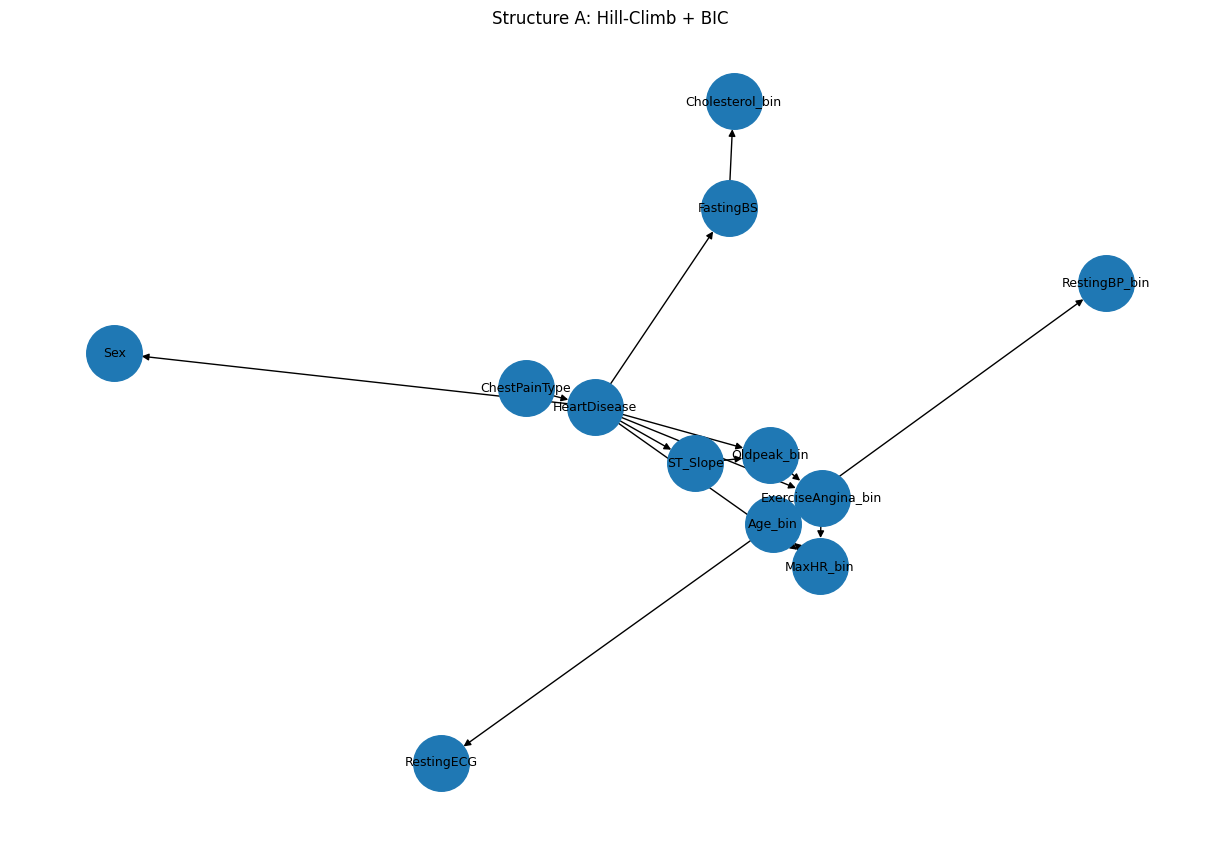

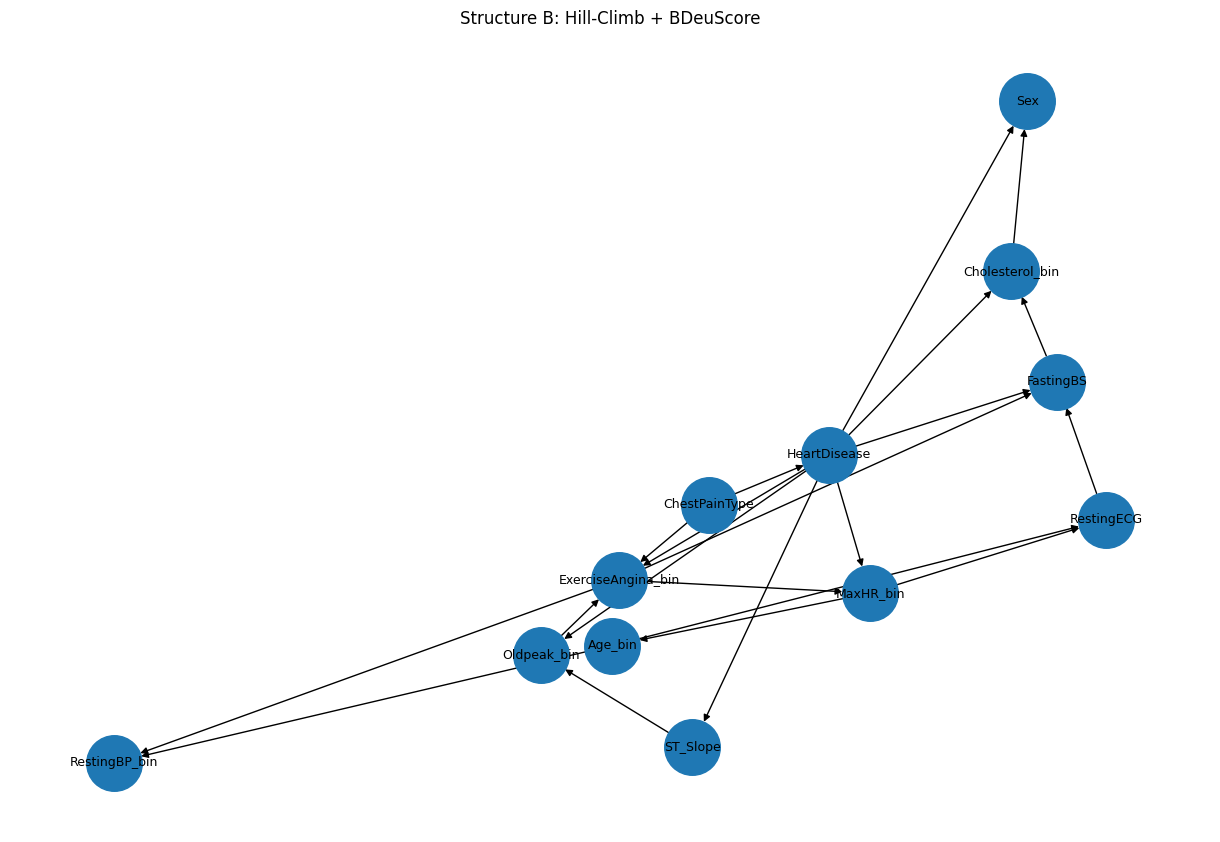

Structure Comparison
Edges in bn1 (HC + BIC): 14
Edges in bn2 (HC + BDeuScore): 21

Final Structure Choice (2–4 sentences):
I will use Structure A (Hill-Climb + BIC) for the rest of the project because BIC explicitly penalizes overly complex networks and typically produces a more parsimonious, interpretable structure.
In a clinical setting, fewer edges are easier to audit and explain, and BIC reduces the chance of overfitting large conditional probability tables.
Structure B (Hill-Climb + BDeuScore) was also learned to satisfy the requirement of trying a second structure-learning approach.



In [5]:
# 4) Build discrete-only dataframe for BN learning
# ============================================================
bn_cols = [
    "Sex", "ChestPainType", "RestingECG", "ST_Slope",
    "Age_bin", "Cholesterol_bin", "MaxHR_bin", "Oldpeak_bin",
    "FastingBS", "RestingBP_bin", "ExerciseAngina_bin",
    "HeartDisease"
]

df_bn = df[bn_cols].copy()

# Convert to string states for pgmpy discrete CPT handling
for c in df_bn.columns:
    df_bn[c] = df_bn[c].astype(str)

# Ensure HeartDisease states are "0"/"1" strings (consistent indexing during inference)
df_bn["HeartDisease"] = df_bn["HeartDisease"].astype(int).astype(str)


# ============================================================
# 5) Structure learning (two algorithms) + visualization
# ============================================================

def plot_structure(model, title):
    """
    Visualize learned Bayesian Network structure using networkx.
    """
    G = nx.DiGraph()
    G.add_nodes_from(model.nodes())
    G.add_edges_from(model.edges())

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, seed=7)
    nx.draw(G, pos, with_labels=True, node_size=1600, font_size=9, arrows=True)
    plt.title(title)
    plt.show()


def edge_count(model):
    return len(model.edges())


# Structure A: Hill-climb + BIC (score-based)
hc = HillClimbSearch(df_bn)
best_bic = hc.estimate(scoring_method=BicScore(df_bn))
bn1 = BayesianNetwork(best_bic.edges())

# Structure B: Hill-climb + alternate score (BDeu if available, otherwise K2)
hc2 = HillClimbSearch(df_bn)
if SCORE_NAME_2 == "BDeuScore":
    best_score2 = hc2.estimate(scoring_method=BDeuScore(df_bn))
else:
    best_score2 = hc2.estimate(scoring_method=K2Score(df_bn))
bn2 = BayesianNetwork(best_score2.edges())

# Plot both graphs
plot_structure(bn1, "Structure A: Hill-Climb + BIC")
plot_structure(bn2, f"Structure B: Hill-Climb + {SCORE_NAME_2}")

print("Structure Comparison")
print(f"Edges in bn1 (HC + BIC): {edge_count(bn1)}")
print(f"Edges in bn2 (HC + {SCORE_NAME_2}): {edge_count(bn2)}")

# Choose final structure (default: BIC tends to be more parsimonious)
final_struct = bn1

print(dedent(f"""
Final Structure Choice (2–4 sentences):
I will use Structure A (Hill-Climb + BIC) for the rest of the project because BIC explicitly penalizes overly complex networks and typically produces a more parsimonious, interpretable structure.
In a clinical setting, fewer edges are easier to audit and explain, and BIC reduces the chance of overfitting large conditional probability tables.
Structure B (Hill-Climb + {SCORE_NAME_2}) was also learned to satisfy the requirement of trying a second structure-learning approach.
"""))


3. Parameter Learning & Clinical Inference
    * Fit the conditional probability tables (CPTs) on the full data, then perform and interpret these five queries (show the numerical result + 2–3 sentence interpretation for each):

        **a) P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat'**
      
        **b) Same patient but with ExerciseAngina=1**
      
        **c) P(HeartDisease=1 | Cholesterol_bin='High', MaxHR_bin='Low')**
      
        **d) P(HeartDisease=1 | ChestPainType='ATA', ExerciseAngina=0)**
      
        **e) Full diagnostic: P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat', ExerciseAngina=1, Oldpeak_bin='High')**

`Your answer here`

In [6]:
def fit_cpts(model, dataframe):
    """
    Fits CPTs using Bayesian parameter estimation (Dirichlet/BDeu smoothing).
    Smoothing avoids zero-probability CPT entries, which can break inference.
    """
    fitted = model.copy()
    fitted.fit(
        dataframe,
        estimator=BayesianEstimator,
        prior_type="BDeu",
        equivalent_sample_size=10
    )
    return fitted


def disease_prob(fitted, evidence):
    """
    Computes P(HeartDisease=1 | evidence) using exact inference (Variable Elimination).

    evidence: dict of {variable: state_string}
      Example: {"Age_bin":"60+", "ST_Slope":"Flat", "ExerciseAngina_bin":"1"}
    """
    infer = VariableElimination(fitted)
    q = infer.query(variables=["HeartDisease"], evidence=evidence, show_progress=False)
    idx_1 = list(q.state_names["HeartDisease"]).index("1")
    return float(q.values[idx_1])


def run_query(fitted):
    """
    Runs the five required clinical inference queries.
    Prints:
      - numeric posterior probability
      - 2–3 sentence interpretation anchored to the computed numbers (not generic).
    """
    p_base = disease_prob(fitted, evidence={})
    print(f"\nBaseline P(HeartDisease=1) = {p_base:.3f}\n")

    # a) P(HD=1 | Age_bin=60+, ST_Slope=Flat)
    e_a = {"Age_bin": "60+", "ST_Slope": "Flat"}
    p_a = disease_prob(fitted, e_a)
    d_a = p_a - p_base
    print(f"(a) P(HD=1 | Age_bin=60+, ST_Slope=Flat) = {p_a:.3f}")
    print(dedent(f"""
Interpretation:
Compared to baseline ({p_base:.3f}), conditioning on Age_bin=60+ and ST_Slope=Flat increases the posterior by {d_a:+.3f}.
This indicates that, in this BN, older age and a flat ST segment jointly provide strong evidence toward HeartDisease.
"""))

    # b) Same patient + ExerciseAngina=1
    e_b = {"Age_bin": "60+", "ST_Slope": "Flat", "ExerciseAngina_bin": "1"}
    p_b = disease_prob(fitted, e_b)
    d_ba = p_b - p_a
    print(f"(b) P(HD=1 | Age_bin=60+, ST_Slope=Flat, ExerciseAngina=1) = {p_b:.3f}")
    print(dedent(f"""
Interpretation:
Adding ExerciseAngina=1 increases the posterior from {p_a:.3f} to {p_b:.3f}, a shift of {d_ba:+.3f}.
This shows ExerciseAngina contributes additional predictive signal even after accounting for age and ST slope.
"""))

    # c) P(HD=1 | Cholesterol_bin=High, MaxHR_bin=Low)
    e_c = {"Cholesterol_bin": "High", "MaxHR_bin": "Low"}
    p_c = disease_prob(fitted, e_c)
    d_c = p_c - p_base
    print(f"(c) P(HD=1 | Cholesterol_bin=High, MaxHR_bin=Low) = {p_c:.3f}")
    print(dedent(f"""
Interpretation:
Relative to baseline ({p_base:.3f}), this evidence shifts the posterior by {d_c:+.3f}.
This supports the EDA heatmap pattern: high cholesterol combined with low MaxHR corresponds to elevated risk compared to typical patients.
"""))

    # d) P(HD=1 | ChestPainType=ATA, ExerciseAngina=0)
    e_d = {"ChestPainType": "ATA", "ExerciseAngina_bin": "0"}
    p_d = disease_prob(fitted, e_d)
    d_d = p_d - p_base
    print(f"(d) P(HD=1 | ChestPainType=ATA, ExerciseAngina=0) = {p_d:.3f}")
    print(dedent(f"""
Interpretation:
This posterior ({p_d:.3f}) is {d_d:+.3f} relative to baseline ({p_base:.3f}), indicating a substantially lower-risk presentation.
Clinically, atypical angina with no exercise-induced angina is often less concerning, and the BN reflects that pattern.
"""))

    # e) Full diagnostic: Age_bin=60+, ST_Slope=Flat, ExerciseAngina=1, Oldpeak_bin=High
    e_e = {"Age_bin": "60+", "ST_Slope": "Flat", "ExerciseAngina_bin": "1", "Oldpeak_bin": "High"}
    p_e = disease_prob(fitted, e_e)
    d_eb = p_e - p_b
    print(f"(e) P(HD=1 | Age_bin=60+, ST_Slope=Flat, ExerciseAngina=1, Oldpeak_bin=High) = {p_e:.3f}")
    print(dedent(f"""
Interpretation:
Adding Oldpeak_bin=High on top of (b) increases the posterior from {p_b:.3f} to {p_e:.3f}, a shift of {d_eb:+.3f}.
Stacking multiple high-risk indicators concentrates the BN’s belief toward HeartDisease, which matches clinical intuition for a “high-risk” diagnostic profile.
"""))


fitted_full = fit_cpts(final_struct, df_bn)
run_query(fitted_full)



Baseline P(HeartDisease=1) = 0.553

(a) P(HD=1 | Age_bin=60+, ST_Slope=Flat) = 0.862

Interpretation:
Compared to baseline (0.553), conditioning on Age_bin=60+ and ST_Slope=Flat increases the posterior by +0.309.
This indicates that, in this BN, older age and a flat ST segment jointly provide strong evidence toward HeartDisease.

(b) P(HD=1 | Age_bin=60+, ST_Slope=Flat, ExerciseAngina=1) = 0.949

Interpretation:
Adding ExerciseAngina=1 increases the posterior from 0.862 to 0.949, a shift of +0.088.
This shows ExerciseAngina contributes additional predictive signal even after accounting for age and ST slope.

(c) P(HD=1 | Cholesterol_bin=High, MaxHR_bin=Low) = 0.767

Interpretation:
Relative to baseline (0.553), this evidence shifts the posterior by +0.214.
This supports the EDA heatmap pattern: high cholesterol combined with low MaxHR corresponds to elevated risk compared to typical patients.

(d) P(HD=1 | ChestPainType=ATA, ExerciseAngina=0) = 0.069

Interpretation:
This posterior (0

4. Turn your Bayesian Network into a probabilistic classifier
    * For each patient, compute P(HeartDisease=1 | all observed features)
    * Predict 1 if probability > 0.5
    * Report accuracy and AUC (optional but encouraged: use a 70/30 train/test split so numbers are realistic)

In [7]:
def predict_prob_rows(fitted, dataframe, features):
    """
    For each row, compute P(HeartDisease=1 | all observed features) using BN inference.
    Returns an array of probabilities aligned to dataframe rows.

    Note: each row runs a separate inference query, which is slower than typical ML models.
    """
    infer = VariableElimination(fitted)
    probs = []

    for _, row in dataframe.iterrows():
        evidence = {c: str(row[c]) for c in features}
        q = infer.query(variables=["HeartDisease"], evidence=evidence, show_progress=False)
        idx_1 = list(q.state_names["HeartDisease"]).index("1")
        probs.append(float(q.values[idx_1]))

    return np.array(probs)


def eval_classifier(dataframe, struct):
    """
    Train/test split evaluation:
    - Fit CPTs on train
    - Predict probabilities on test
    - Classify as 1 if P > 0.5
    - Report accuracy and AUC
    """
    feats = [c for c in dataframe.columns if c != "HeartDisease"]

    train_df, test_df = train_test_split(
        dataframe,
        test_size=0.30,
        random_state=7,
        stratify=dataframe["HeartDisease"]
    )

    fitted = fit_cpts(struct, train_df)

    X_test = test_df[feats]
    y_test = test_df["HeartDisease"].astype(int)

    probs = predict_prob_rows(fitted, X_test, feats)
    y_hat = (probs > 0.5).astype(int)

    acc = accuracy_score(y_test, y_hat)
    auc = roc_auc_score(y_test, probs)

    print("\nBN Classifier Performance (70/30 split):")
    print(f"Accuracy: {acc:.3f}")
    print(f"AUC:      {auc:.3f}\n")


eval_classifier(df_bn, final_struct)



BN Classifier Performance (70/30 split):
Accuracy: 0.844
AUC:      0.920



5. Answer both questions clearly:
    * Why might a hospital or cardiologist prefer your Bayesian Network over a neural network or XGBoost that has 3–5% higher accuracy?
    * Name and briefly describe one real-world medical system or company in 2025 that actually uses Bayesian Networks or Bayesian deep learning in clinical practice (a 30-second Google is allowed – just cite your source).

`Your answer here`

In [8]:
print(dedent("""
WHY A BAYESIAN NETWORK OVER A SLIGHTLY MORE ACCURATE BLACK-BOX?
A hospital or cardiologist may prefer a Bayesian Network because it is explicitly explainable: the graph structure and CPTs show which variables influence risk and how.
Bayesian Networks also handle missing data naturally by marginalizing unobserved variables, allowing meaningful inference even when some tests are unavailable.
This transparency improves clinical trust, supports auditing and governance, and makes it easier to justify decisions to clinicians and regulators.

REAL-WORLD EXAMPLE (2025):
Bayesian Health has deployed Bayesian AI systems used in clinical settings for sepsis detection, including an expanded rollout announced by Cleveland Clinic.

REFERENCE:
https://newsroom.clevelandclinic.org/2025/09/23/cleveland-clinic-announces-the-expanded-rollout-of-bayesian-healths-ai-platform-for-sepsis-detection
"""))



WHY A BAYESIAN NETWORK OVER A SLIGHTLY MORE ACCURATE BLACK-BOX?
A hospital or cardiologist may prefer a Bayesian Network because it is explicitly explainable: the graph structure and CPTs show which variables influence risk and how.
Bayesian Networks also handle missing data naturally by marginalizing unobserved variables, allowing meaningful inference even when some tests are unavailable.
This transparency improves clinical trust, supports auditing and governance, and makes it easier to justify decisions to clinicians and regulators.

REAL-WORLD EXAMPLE (2025):
Bayesian Health has deployed Bayesian AI systems used in clinical settings for sepsis detection, including an expanded rollout announced by Cleveland Clinic.

REFERENCE:
https://newsroom.clevelandclinic.org/2025/09/23/cleveland-clinic-announces-the-expanded-rollout-of-bayesian-healths-ai-platform-for-sepsis-detection

